# Proyecto Etapa 1

### Cargando el entorno de PySpark en Goolge Colab

In [10]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

In [11]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

In [12]:
!ls

sample_data		 spark-3.5.8-bin-hadoop3.tgz
spark-3.5.8-bin-hadoop3  spark-3.5.8-bin-hadoop3.tgz.1


In [13]:
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
#spark = SparkSession.builder.master("local[*]").getOrCreate()
spark = SparkSession.builder \
                    .master("local[*]") \
                    .appName("Ejemplo") \
                    .getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

### Conectando con una base de datos desde Google Drive

In [14]:
import os
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Colab Notebooks/MNA/BigData/ProyectoEtapa1/Microsoft_GUIDE_Train.csv"

Mounted at /content/drive


## Creando un Dataframe a partir de un archivo "csv" de entrada

In [15]:
df = spark.read.csv(file_path, header=True, sep=",", inferSchema=True)
df.show(10)

+-------------+-----+----------+-------+-------------------+----------+----------+------------------+---------------+--------------+-------------+--------------+-----------+------------+--------+------+---------+------+----------+----------+---------------+-----------+----------+----------------+--------------+-----------+-----------------+-----------------+-------------+---------------+------------------+------------+--------+----------+--------------+------------+-----+--------+---------+-----------------+--------------+-----------+-----------+-----+-----+
|           Id|OrgId|IncidentId|AlertId|          Timestamp|DetectorId|AlertTitle|          Category|MitreTechniques| IncidentGrade|ActionGrouped|ActionGranular| EntityType|EvidenceRole|DeviceId|Sha256|IpAddress|   Url|AccountSid|AccountUpn|AccountObjectId|AccountName|DeviceName|NetworkMessageId|EmailClusterId|RegistryKey|RegistryValueName|RegistryValueData|ApplicationId|ApplicationName|OAuthApplicationId|ThreatFamily|FileName|Fold

##Análisis Exploratorio de Datos

#### Descripción General del Dataset

In [16]:
# Número de filas y columnas
num_rows = df.count()
num_cols = len(df.columns)

print(f"Número de registros: {num_rows}")
print(f"Número de columnas: {num_cols}")

Número de registros: 9516837
Número de columnas: 45


In [17]:
# Nombres de columnas
print(df.columns)

['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId', 'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade', 'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole', 'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId', 'EmailClusterId', 'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath', 'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode', 'State', 'City']


In [18]:
# Tipos de datos
# Variables categóricas (string)
# Variables numéricas (integer, double)
# Variables temporales (timestamp)

df.printSchema()

root
 |-- Id: long (nullable = true)
 |-- OrgId: integer (nullable = true)
 |-- IncidentId: integer (nullable = true)
 |-- AlertId: integer (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- DetectorId: integer (nullable = true)
 |-- AlertTitle: integer (nullable = true)
 |-- Category: string (nullable = true)
 |-- MitreTechniques: string (nullable = true)
 |-- IncidentGrade: string (nullable = true)
 |-- ActionGrouped: string (nullable = true)
 |-- ActionGranular: string (nullable = true)
 |-- EntityType: string (nullable = true)
 |-- EvidenceRole: string (nullable = true)
 |-- DeviceId: integer (nullable = true)
 |-- Sha256: integer (nullable = true)
 |-- IpAddress: integer (nullable = true)
 |-- Url: integer (nullable = true)
 |-- AccountSid: integer (nullable = true)
 |-- AccountUpn: integer (nullable = true)
 |-- AccountObjectId: integer (nullable = true)
 |-- AccountName: integer (nullable = true)
 |-- DeviceName: integer (nullable = true)
 |-- NetworkMessageId: i

In [19]:
# Imprimiendo los tipos de datos del Dataframe
df.dtypes

[('Id', 'bigint'),
 ('OrgId', 'int'),
 ('IncidentId', 'int'),
 ('AlertId', 'int'),
 ('Timestamp', 'timestamp'),
 ('DetectorId', 'int'),
 ('AlertTitle', 'int'),
 ('Category', 'string'),
 ('MitreTechniques', 'string'),
 ('IncidentGrade', 'string'),
 ('ActionGrouped', 'string'),
 ('ActionGranular', 'string'),
 ('EntityType', 'string'),
 ('EvidenceRole', 'string'),
 ('DeviceId', 'int'),
 ('Sha256', 'int'),
 ('IpAddress', 'int'),
 ('Url', 'int'),
 ('AccountSid', 'int'),
 ('AccountUpn', 'int'),
 ('AccountObjectId', 'int'),
 ('AccountName', 'int'),
 ('DeviceName', 'int'),
 ('NetworkMessageId', 'int'),
 ('EmailClusterId', 'double'),
 ('RegistryKey', 'int'),
 ('RegistryValueName', 'int'),
 ('RegistryValueData', 'int'),
 ('ApplicationId', 'int'),
 ('ApplicationName', 'int'),
 ('OAuthApplicationId', 'int'),
 ('ThreatFamily', 'string'),
 ('FileName', 'int'),
 ('FolderPath', 'int'),
 ('ResourceIdName', 'int'),
 ('ResourceType', 'string'),
 ('Roles', 'string'),
 ('OSFamily', 'int'),
 ('OSVersion', '

#### Valores Faltantes

In [20]:
# Total de valores faltantes
from pyspark.sql.functions import col, sum

missing_total = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing_total.show()

+---+-----+----------+-------+---------+----------+----------+--------+---------------+-------------+-------------+--------------+----------+------------+--------+------+---------+---+----------+----------+---------------+-----------+----------+----------------+--------------+-----------+-----------------+-----------------+-------------+---------------+------------------+------------+--------+----------+--------------+------------+-------+--------+---------+-----------------+--------------+-----------+-----------+-----+----+
| Id|OrgId|IncidentId|AlertId|Timestamp|DetectorId|AlertTitle|Category|MitreTechniques|IncidentGrade|ActionGrouped|ActionGranular|EntityType|EvidenceRole|DeviceId|Sha256|IpAddress|Url|AccountSid|AccountUpn|AccountObjectId|AccountName|DeviceName|NetworkMessageId|EmailClusterId|RegistryKey|RegistryValueName|RegistryValueData|ApplicationId|ApplicationName|OAuthApplicationId|ThreatFamily|FileName|FolderPath|ResourceIdName|ResourceType|  Roles|OSFamily|OSVersion|Antispa

In [21]:
# Columnas con valores faltantes
missing_columns = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).toPandas()

missing_columns = missing_columns.T
missing_columns.columns = ["missing_count"]

missing_columns = missing_columns[missing_columns["missing_count"] > 0]

print(missing_columns)

                   missing_count
MitreTechniques          5468386
IncidentGrade              51340
ActionGrouped            9460773
ActionGranular           9460773
EmailClusterId           9420025
ThreatFamily             9441956
ResourceType             9509762
Roles                    9298686
AntispamDirection        9339535
SuspicionLevel           8072708
LastVerdict              7282572


#### Validar duplicados

In [22]:
registros_unicos = df.distinct().count()
duplicados = num_rows - registros_unicos

print(f"Total registros: {num_rows}")
print(f"Registros únicos: {registros_unicos}")
print(f"Registros duplicados: {duplicados}")

Total registros: 9516837
Registros únicos: 9494278
Registros duplicados: 22559


#### Distribución de variable objetivo

In [23]:
from pyspark.sql.functions import count

total = df.count()

df.groupBy("IncidentGrade") \
  .agg(count("*").alias("count")) \
  .withColumn("percentage", col("count") / total * 100) \
  .show()

+--------------+-------+-----------------+
| IncidentGrade|  count|       percentage|
+--------------+-------+-----------------+
|          NULL|  51340|0.539464950382149|
|BenignPositive|4110817|43.19520235557255|
| FalsePositive|2031967|21.35128509608812|
|  TruePositive|3322713|34.91404759795718|
+--------------+-------+-----------------+



#### ANÁLISIS UNIVARIADO – VARIABLES NUMÉRICAS

In [24]:
# Estadísticas descriptivas
df.describe().show()


+-------+--------------------+------------------+------------------+------------------+-----------------+------------------+----------+---------------+--------------+--------------------+--------------------+--------------------+------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+--------------------+------------------+------------------+-----------------+--------------------+----------+------------------+----------------+--------------------+--------------+--------------------+------------------+------------------+------------------+
|summary|                  Id|             OrgId|        IncidentId|           AlertId|       DetectorId|        AlertTitle|  Category|MitreTechniques| IncidentGrade|       Ac

In [30]:
# Identificar columnas numéricas

from pyspark.sql.types import NumericType

numeric_cols = [
    f.name for f in df.schema.fields
    if isinstance(f.dataType, NumericType)
]

print(numeric_cols)

['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'AlertTitle', 'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId', 'EmailClusterId', 'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'FileName', 'FolderPath', 'ResourceIdName', 'OSFamily', 'OSVersion', 'CountryCode', 'State', 'City']


In [37]:
# Se toma una muestra del dataframe (PySpark → Pandas para visualización)
sample_df = df.select(numeric_cols).sample(fraction=0.001).toPandas()

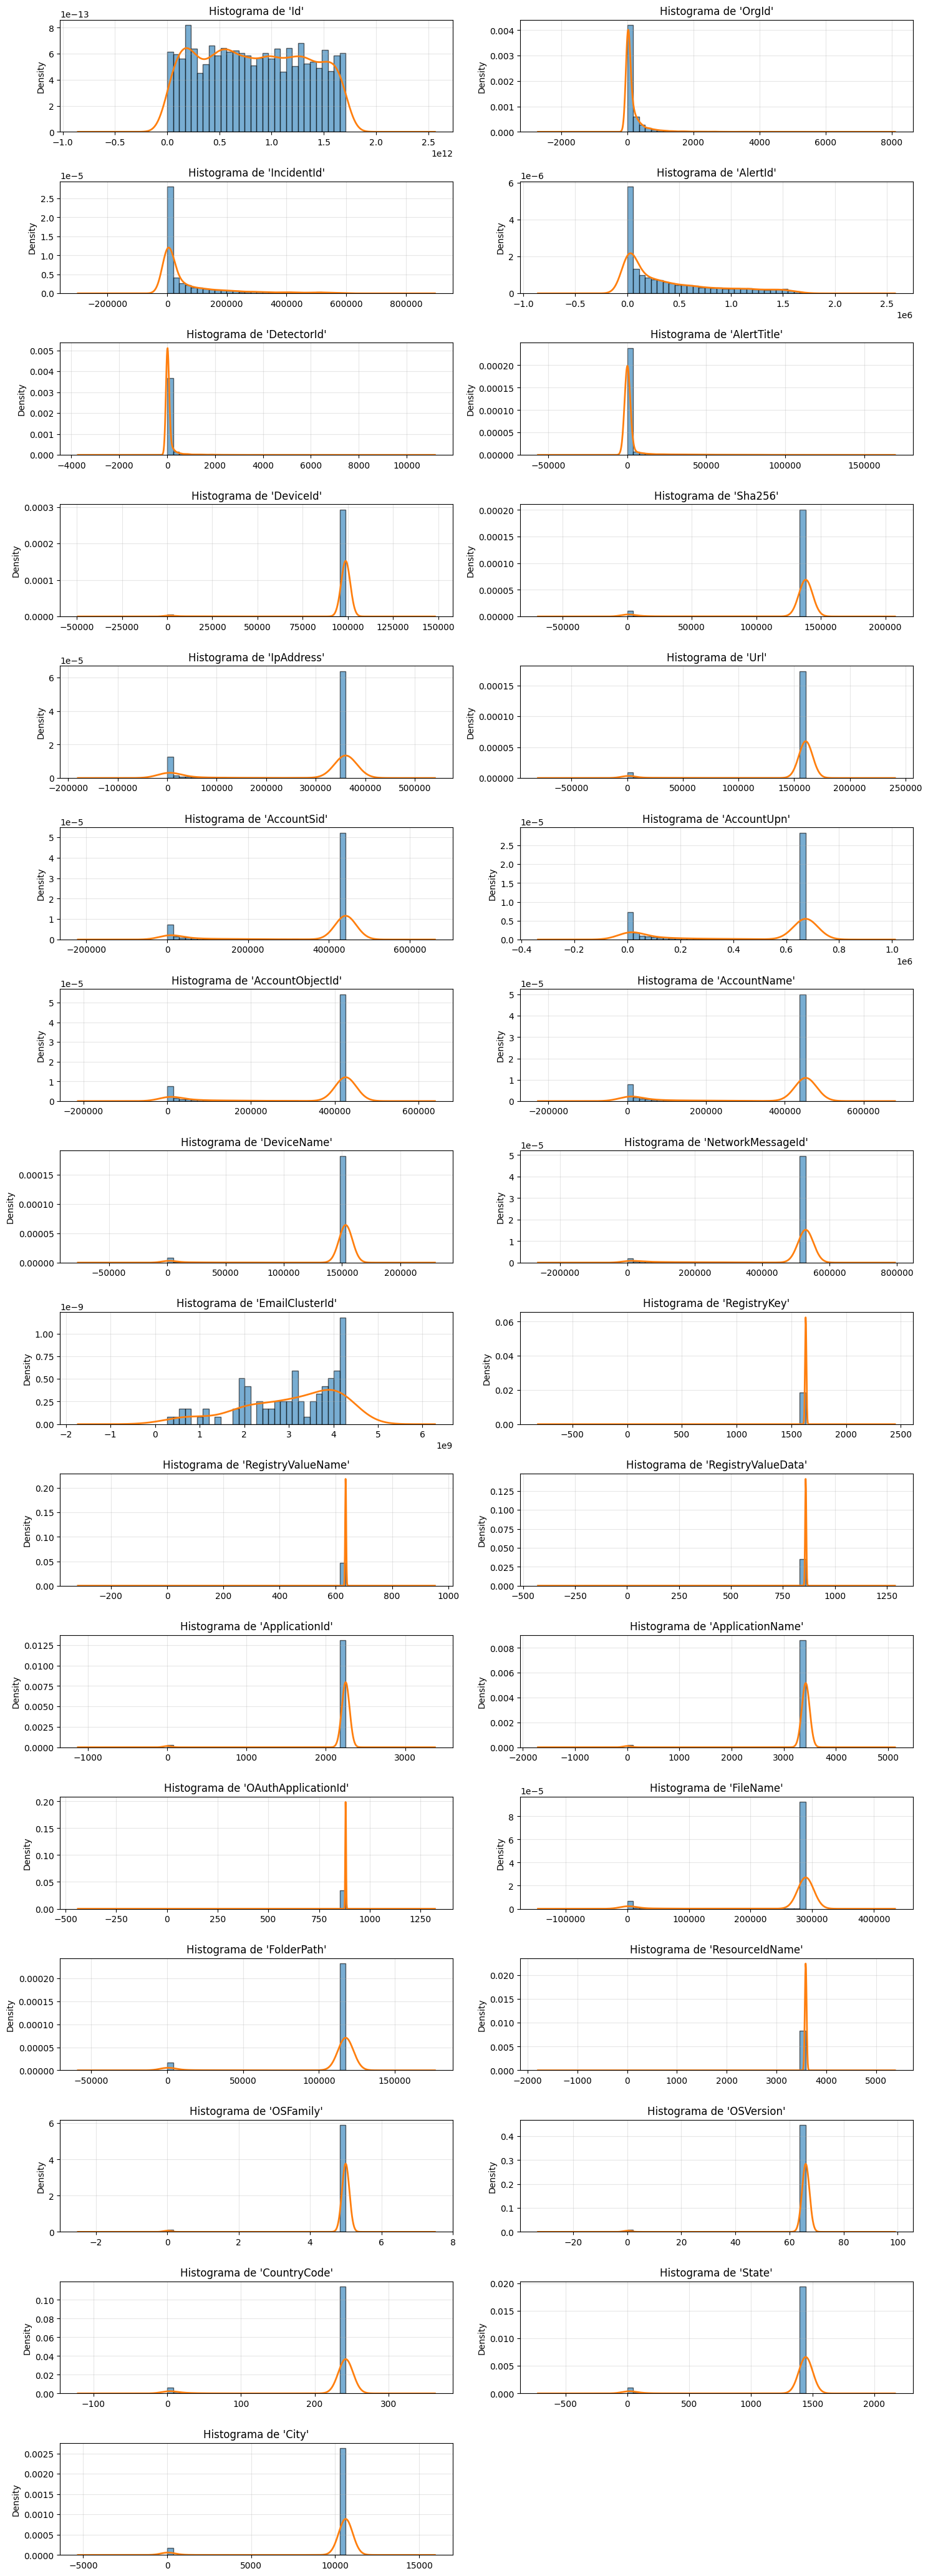

In [38]:
# Histograma con KDE para indenficar asimetría y curtosis
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 80))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(round(len(numeric_cols)), 2, i)
    sample_df[col].plot.hist(bins=30, edgecolor="black", density=True, alpha=0.6, title=f"Histograma de '{col}'")
    sample_df[col].plot.kde(linewidth=2)
    plt.grid(alpha=0.3)
plt.tight_layout()

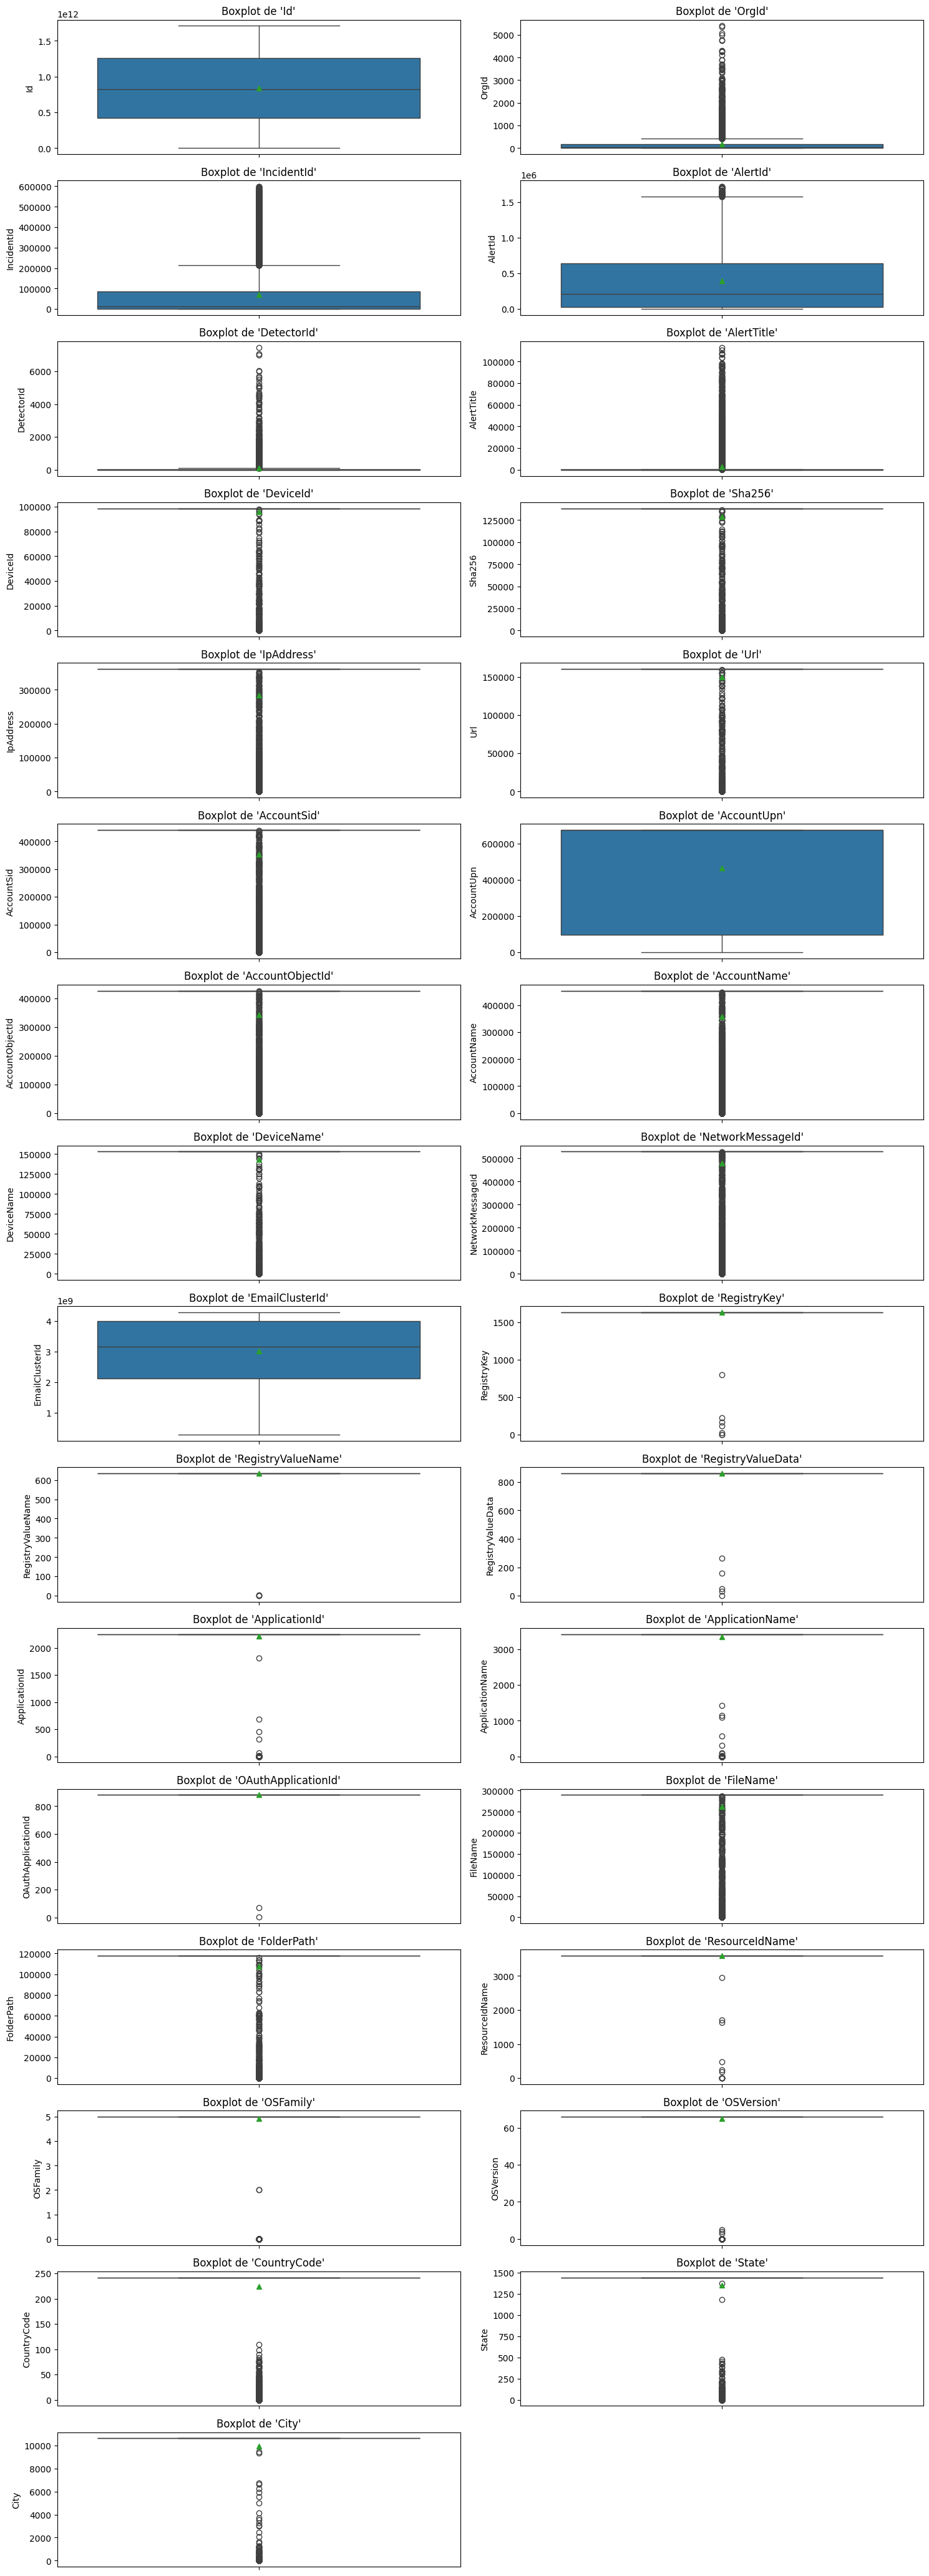

In [39]:
# Boxplot para identificar outliers
import seaborn as sns

plt.figure(figsize=(15, 80))
for i, col in enumerate(numeric_cols, 1):
  plt.subplot(round(len(numeric_cols)), 2, i)
  sns.boxplot(data=sample_df, y=col, showmeans=True)
  plt.title(f"Boxplot de '{col}'")
plt.tight_layout()

#### ANÁLISIS UNIVARIADO – VARIABLES CATEGORICAS

In [41]:
# Identificar columnas categóricas (nominales, ordinales o binarias)
from pyspark.sql.types import StringType

categorical_cols = [
    f.name for f in df.schema.fields
    if isinstance(f.dataType, StringType)
]

print("Columnas categóricas (string):", categorical_cols)


Columnas categóricas (string): ['Category', 'MitreTechniques', 'IncidentGrade', 'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole', 'ThreatFamily', 'ResourceType', 'Roles', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict']


In [42]:
# Frecuencia
for col_name in categorical_cols[:5]:  # limitar para no saturar
    print(f"\nColumna: {col_name}")
    df.groupBy(col_name).count().orderBy("count", ascending=False).show(10)


Columna: Category
+------------------+-------+
|          Category|  count|
+------------------+-------+
|     InitialAccess|4293041|
|      Exfiltration|1577965|
|SuspiciousActivity|1003933|
| CommandAndControl| 826691|
|            Impact| 750885|
|  CredentialAccess| 300518|
|         Execution| 267594|
|           Malware| 144081|
|         Discovery| 129342|
|       Persistence|  72682|
+------------------+-------+
only showing top 10 rows


Columna: MitreTechniques
+--------------------+-------+
|     MitreTechniques|  count|
+--------------------+-------+
|                NULL|5468386|
|     T1078;T1078.004|1354904|
|           T1566.002| 814308|
|               T1566| 659591|
|               T1133| 145579|
|           T1566.001| 136892|
|T1110;T1110.003;T...|  88661|
|     T1087;T1087.002|  54564|
|               T1110|  41768|
|         T1078;T1098|  40342|
+--------------------+-------+
only showing top 10 rows


Columna: IncidentGrade
+--------------+-------+
| IncidentGrad

In [49]:
# Se toma una muestra del dataframe (PySpark → Pandas para visualización)
sample_df_cat = df.select(categorical_cols).sample(fraction=0.001).toPandas()

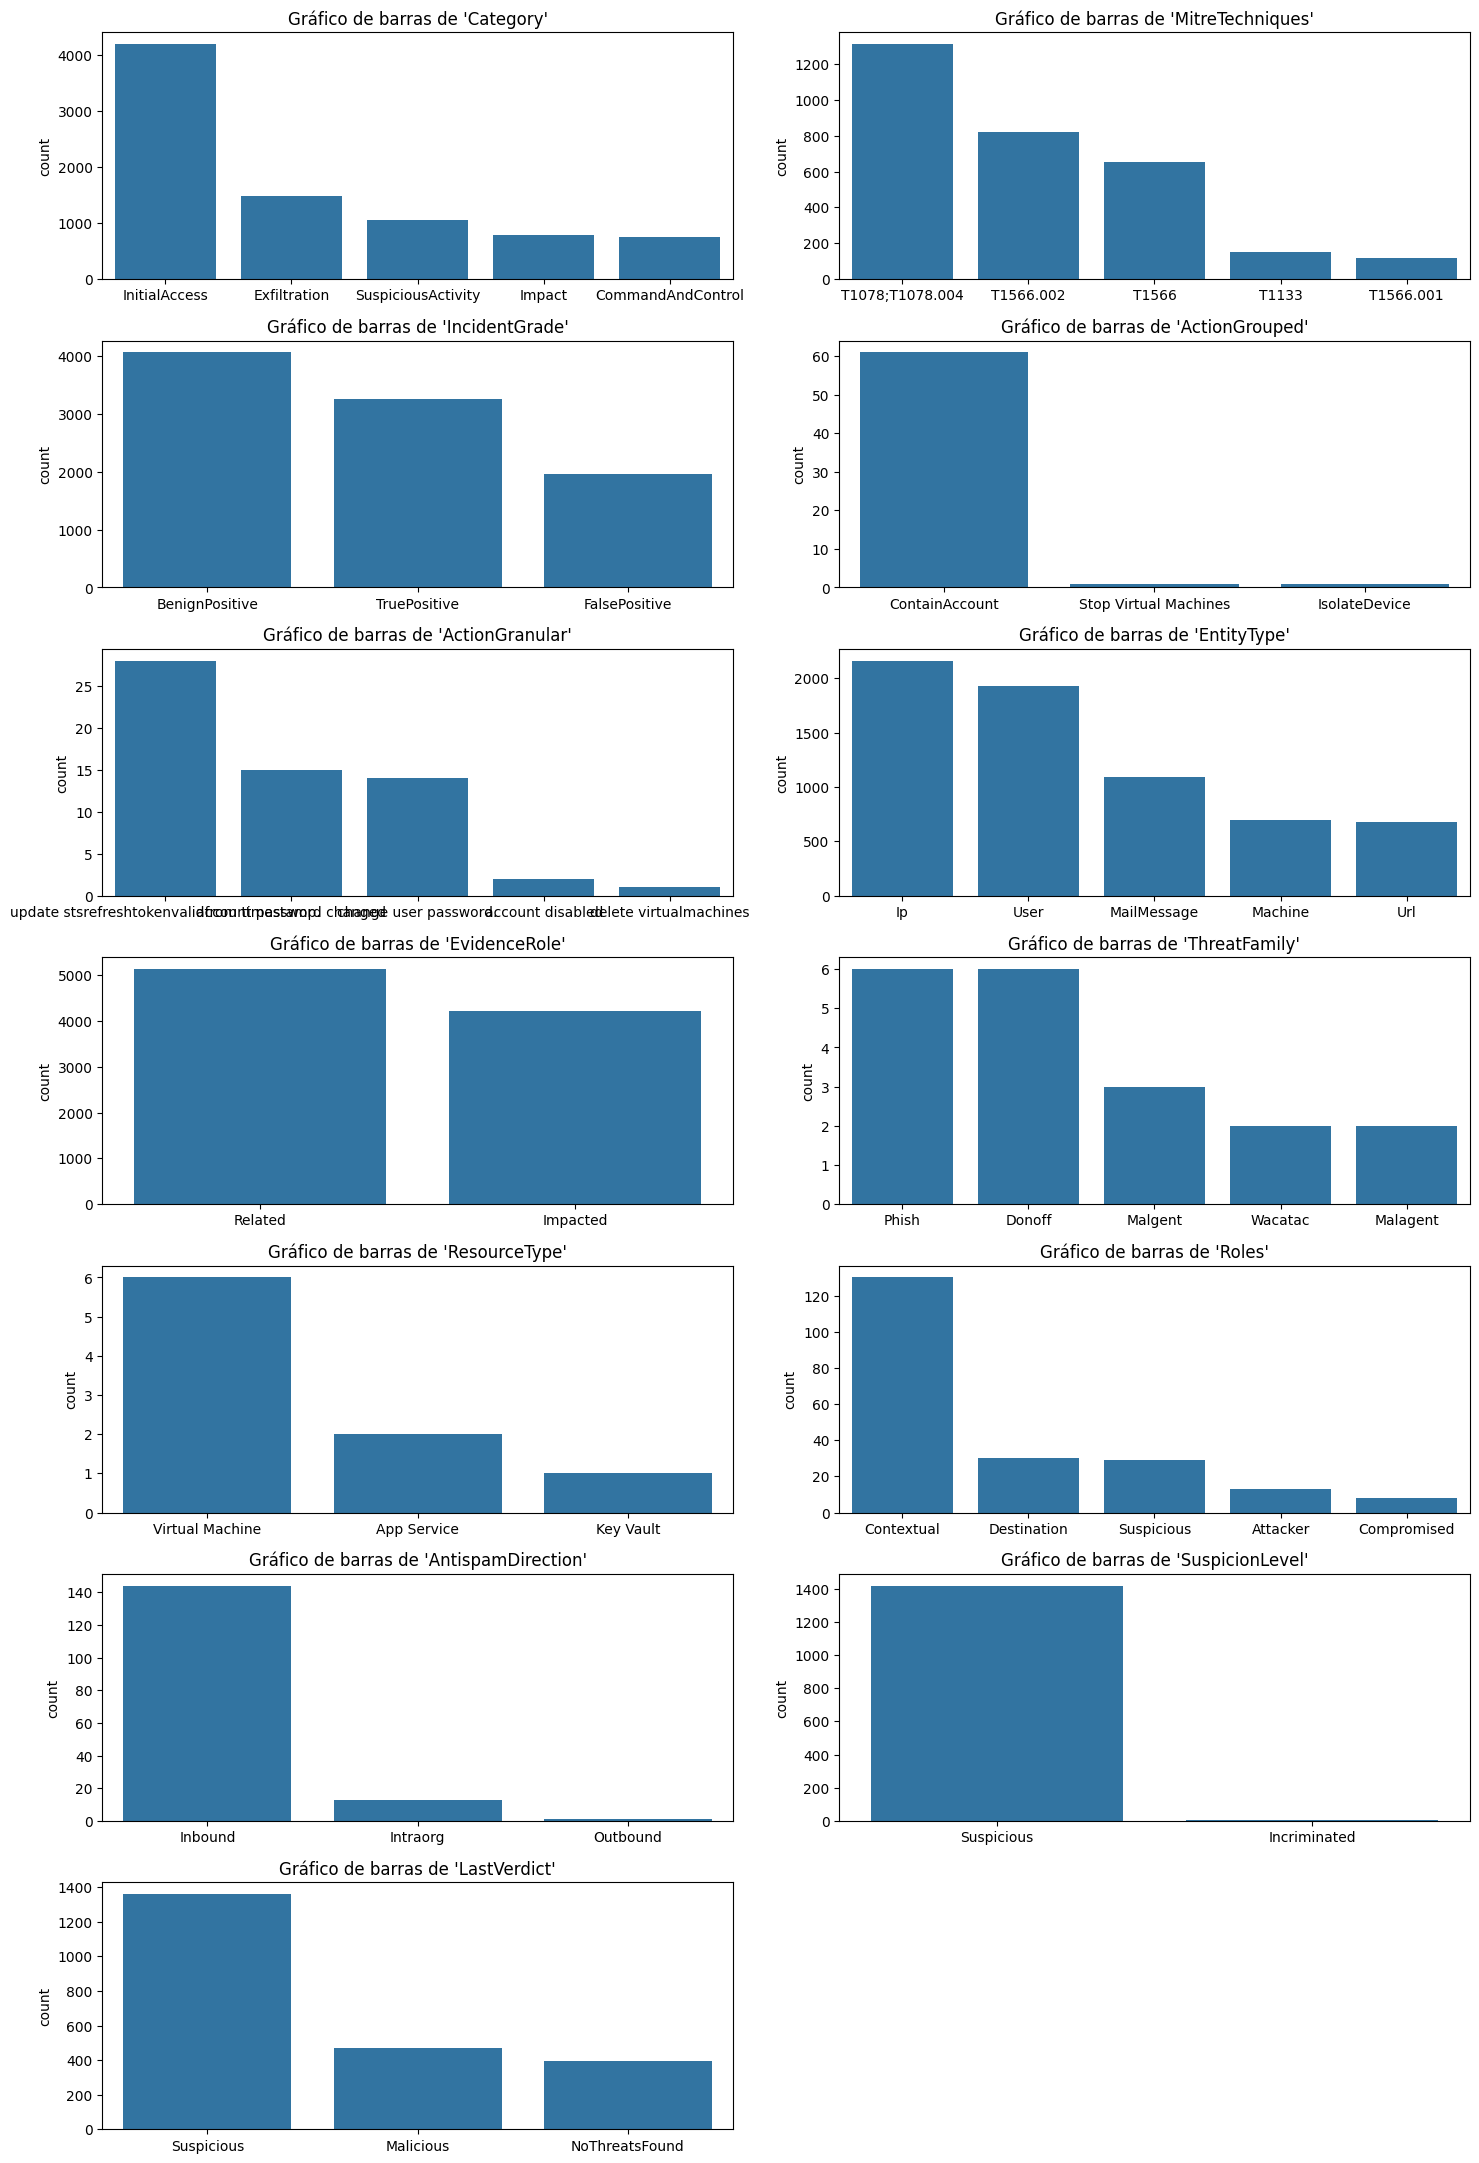

In [53]:
# Gráficos de barras
import seaborn as sns

plt.figure(figsize=(15, 40))
for i, col in enumerate(categorical_cols , 1):
    plt.subplot(round(len(categorical_cols )), 2, i)
    sns.countplot(data=sample_df_cat, x=col, order=sample_df_cat[col].value_counts().head(5).index)
    plt.title(f"Gráfico de barras de '{col}'")
    plt.xlabel("")  # sin etiqueta para ahorrar espacio
plt.tight_layout()


#### ANÁLISIS BIVARIADO

In [57]:
# Tabla cruzada Numéricas vs Objetivo
#for col_name in numeric_cols:
#    df.groupBy("IncidentGrade").avg(col_name).show()


In [58]:
# Tabla Cruzada Categóricas vs Objetivo
#for col_name in categorical_cols[:5]:
#    df.crosstab(col_name, "IncidentGrade").show()

In [59]:
# Correlaciones de variables numéricas (coloreado por variable objetivo)
#import seaborn as sns

#df_plot = sample_df
#df_plot['IncidentGrade'] = sample_df_cat['IncidentGrade']

#plt.figure(figsize=(15,5))
#sns.pairplot(data=df_plot, vars=numeric_cols, hue="IncidentGrade", palette={"BenignPositive": 'skyblue', "FalsePositive": 'skyblue', "TruePositive": 'salmon'}, diag_kind="kde", height=2)
#plt.tight_layout()


Procesando: Category


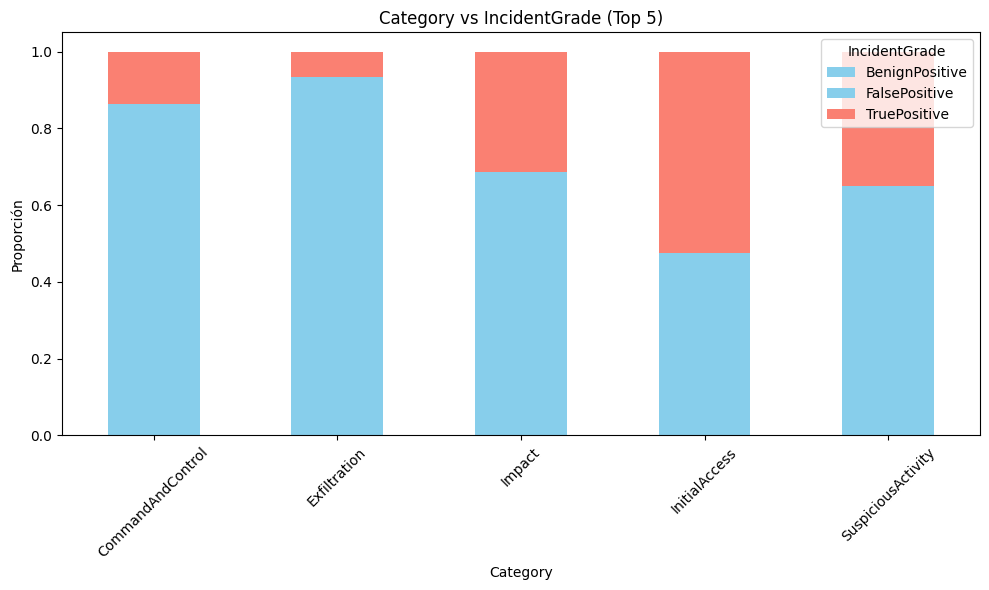


Procesando: MitreTechniques


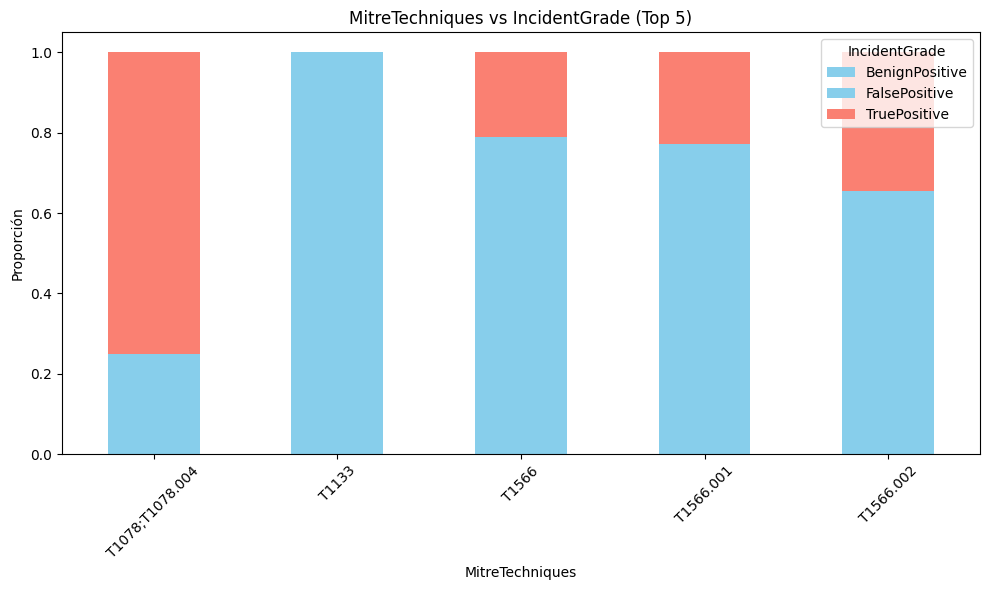


Procesando: ActionGrouped


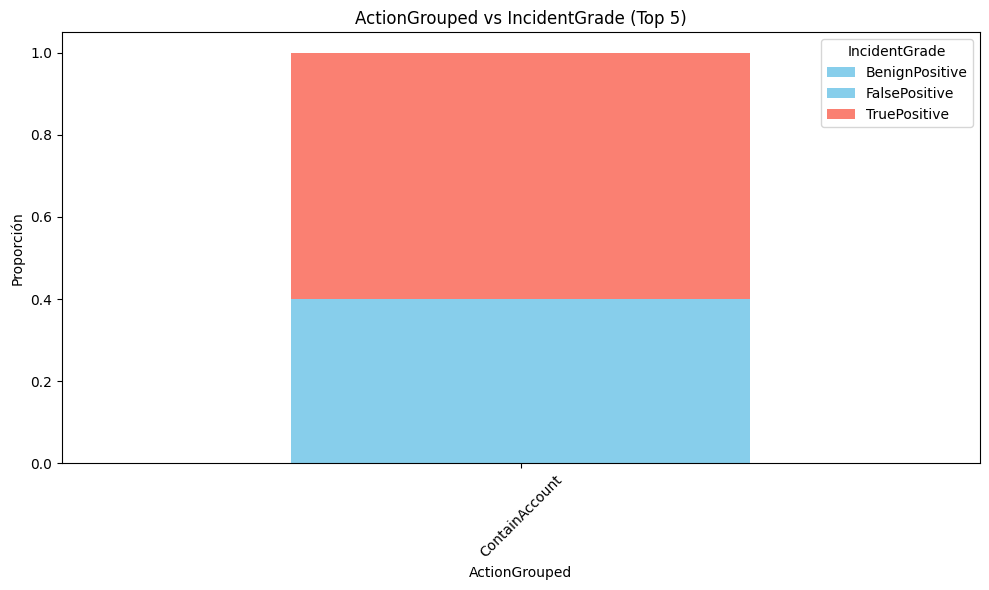


Procesando: ActionGranular


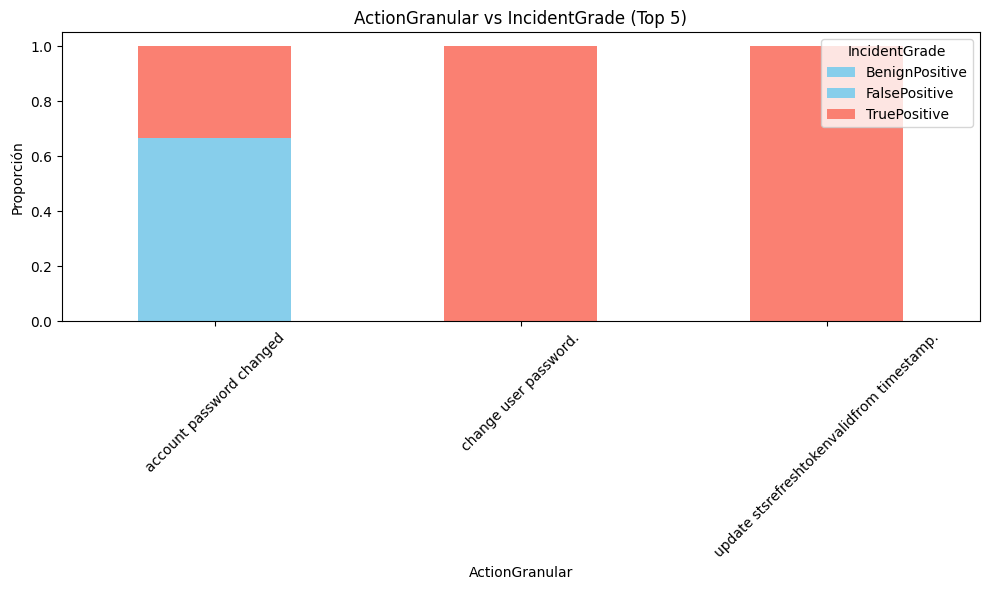


Procesando: EntityType


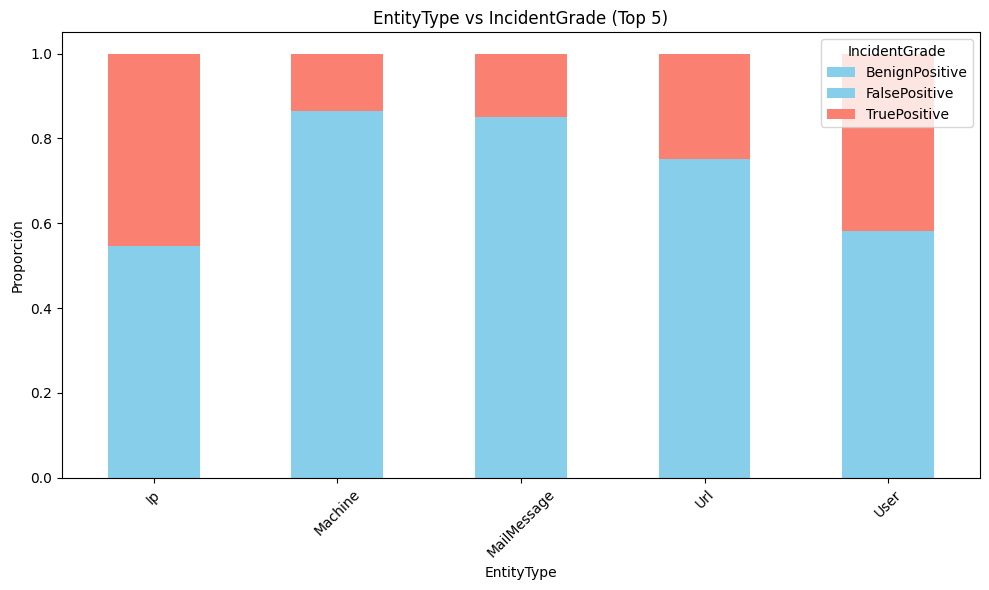


Procesando: EvidenceRole


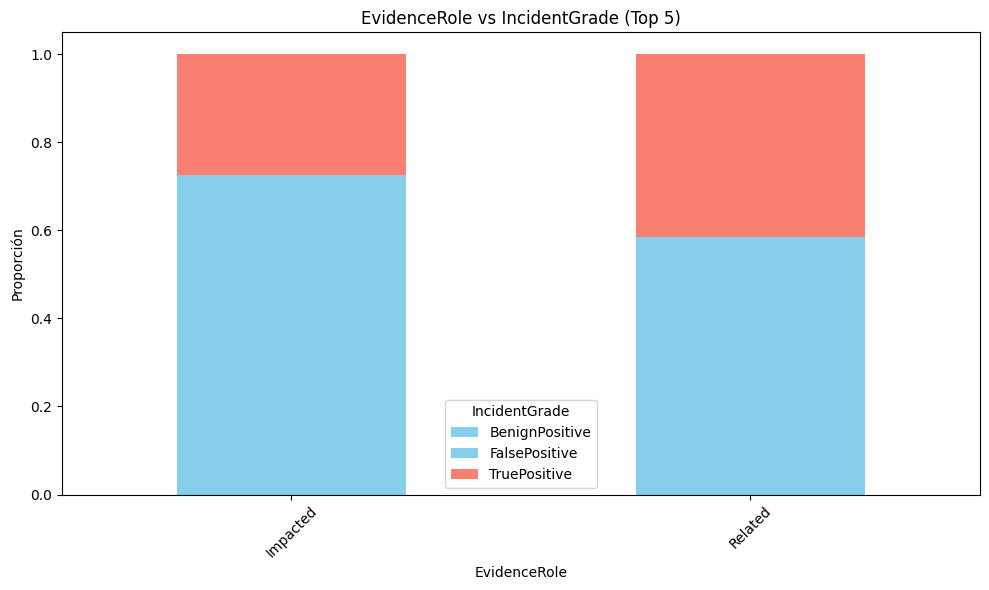


Procesando: ThreatFamily


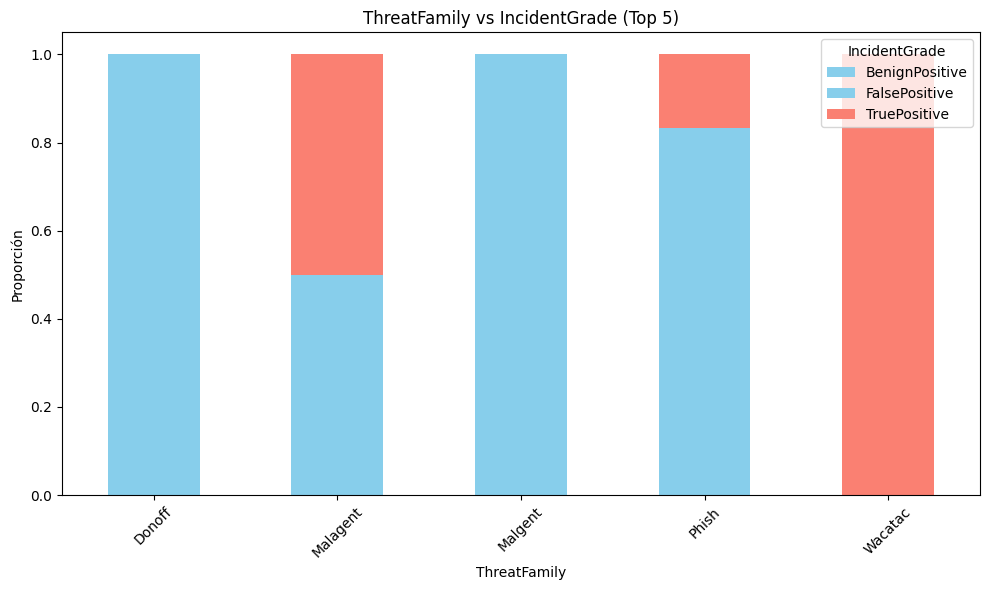


Procesando: ResourceType


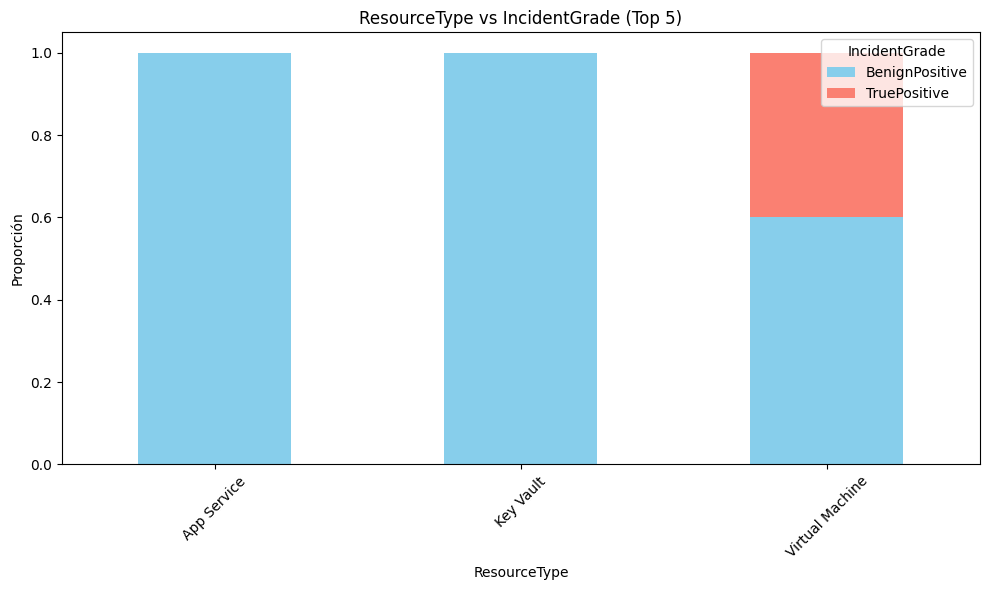


Procesando: Roles


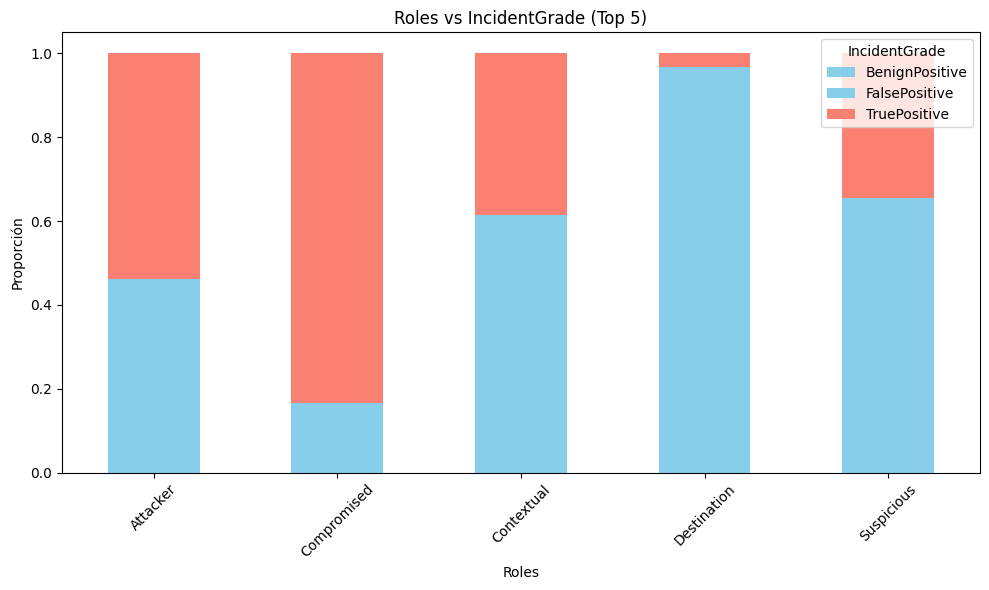


Procesando: AntispamDirection


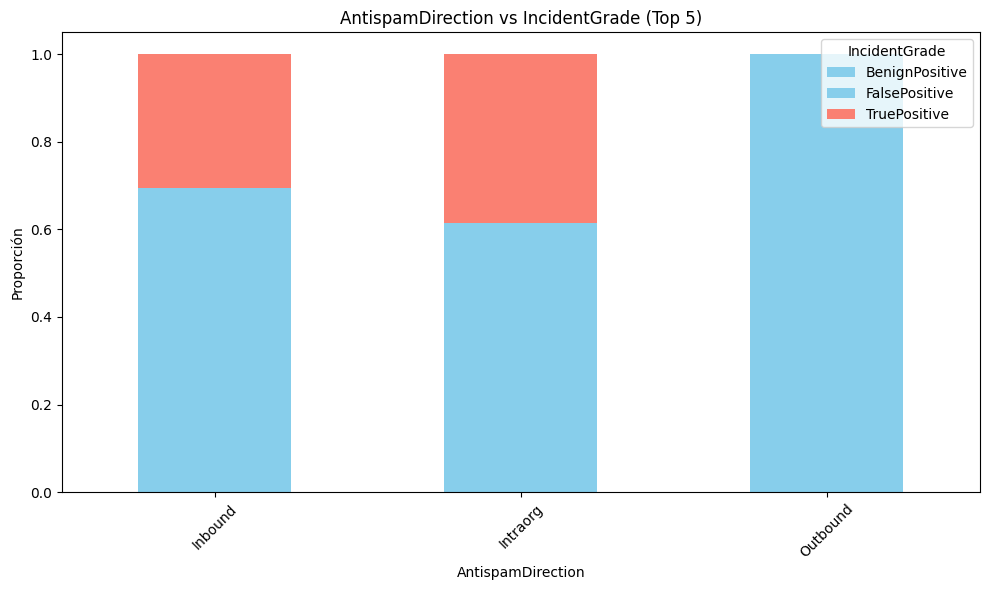


Procesando: SuspicionLevel


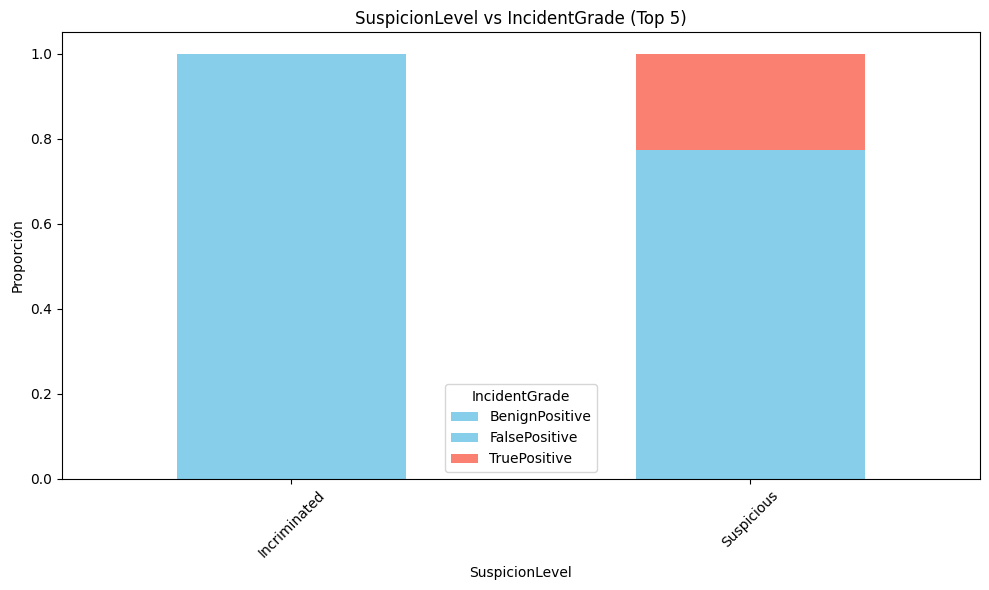


Procesando: LastVerdict


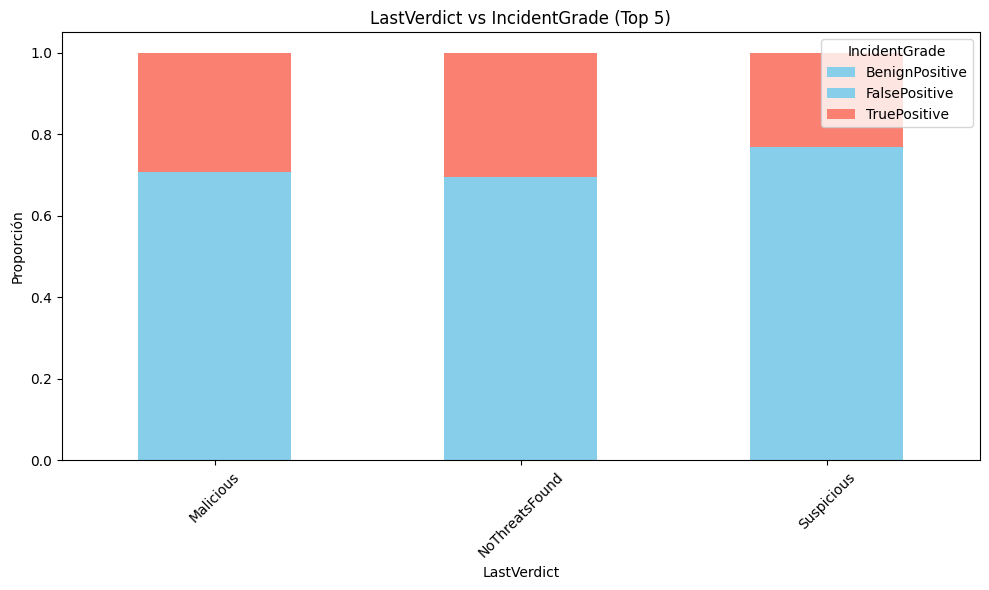

In [73]:
# Barras apiladas de variables categoricas por variable objetivo

import pandas as pd
import matplotlib.pyplot as plt

# Lista de columnas categóricas (excluyendo el target)
cat_cols = [col for col in sample_df_cat.columns if col != "IncidentGrade"]


for col in cat_cols:
    print(f"\nProcesando: {col}")

    # Top 5 categorías más frecuentes
    top_categories = sample_df_cat[col].value_counts().nlargest(5).index

    df_filtered = sample_df_cat[sample_df_cat[col].isin(top_categories)]

    # Tabla cruzada
    crosstab = pd.crosstab(df_filtered[col], df_filtered["IncidentGrade"])

    # Normalizar (opcional pero recomendado)
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)

    # Definir colores
    colors = []
    for grade in crosstab_pct.columns:
        if grade == "TruePositive":
            colors.append("salmon")
        else:
            colors.append("skyblue")

    # Plot
    ax = crosstab_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(10,6),
        color=colors
    )

    plt.title(f"{col} vs IncidentGrade (Top 5)")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(title="IncidentGrade")
    plt.tight_layout()

    plt.show()